# Dashboard Ejecutivo Agropecuario

Este notebook presenta un panel ejecutivo para la toma de decisiones comerciales en el sector agropecuario argentino, integrando datos financieros, análisis estadístico y recomendaciones de IA. Basado en el análisis del cuaderno de automatización y web scraping.

## 1. Importar Librerías y Configuración Inicial

Importa las librerías necesarias para análisis y visualización de datos. Configura el entorno para gráficos y carga de variables.

In [ ]:
# Instalar dependencias necesarias
!pip install -q pandas numpy matplotlib seaborn yfinance #Yahoo Finance API

In [2]:
# Importar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import os
from IPython.display import display, Markdown
import json
print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Carga de Datos Financieros y Estadísticos

Carga los datos de cotizaciones actuales, márgenes por cultivo y alertas generadas. Puedes adaptar la fuente de datos según tu sistema (archivos, API, variables).

**Fuentes de datos, en orden de prioridad:**

1. **Archivos JSON** (`cotizaciones_actuales.json`, `resultados_margenes.json`, `alertas_comerciales.json`), generados por `module-2-llm-api-rag/04-Automatizacion-Web-Scraping.ipynb`.
2. **Yahoo Finance en vivo**: si no existen los JSON, el notebook trae las cotizaciones actuales (`ZS=F` Soja, `ZC=F` Maíz, `ZW=F` Trigo, `USDARS=X` Dólar) y recalcula márgenes y alertas con la misma lógica que el notebook de scraping.
3. **Datos de ejemplo (mock)**: si tampoco hay conexión a internet, se generan datos ficticios con la misma estructura, solo para poder explorar el dashboard.

**Estructura de los datos:**

- `cotizaciones_actuales`: dict `{ "Soja": {"precio": 380.5}, "Maíz": {"precio": 195.2}, ..., "Dólar": {"precio": 1150.0} }` — cada commodity mapea a un dict con al menos la clave `precio`.
- `resultados_margenes`: lista de dicts, cada uno con `cultivo`, `margen_bruto_usd` y `margen_porcentaje`.
- `oportunidades`: lista de dicts con `commodity`, `tipo` (`VENTA`, `RETENER`, `ACUMULAR`, ...), `urgencia` (`ALTA`/`MEDIA`/`BAJA`), `accion` y `fundamento`.

In [3]:
# Lógica portada de 04-Automatizacion-Web-Scraping.ipynb para traer y analizar
# cotizaciones en vivo desde Yahoo Finance cuando no hay archivos JSON disponibles.

COMMODITIES_TICKERS = {
    'Soja': 'ZS=F',       # Soybean Futures - CBOT
    'Maíz': 'ZC=F',      # Corn Futures - CBOT
    'Trigo': 'ZW=F',     # Wheat Futures - CBOT
    'Dólar': 'USDARS=X', # Tipo de cambio USD/ARS
}

# Los futuros de granos en CBOT cotizan en centavos de USD por bushel;
# hay que dividir por 100 para obtener USD/bu. El dólar ya viene en unidades correctas.
COMMODITIES_EN_CENTAVOS = {'Soja', 'Maíz', 'Trigo'}

# Costos de producción por hectárea (USD) y rendimiento promedio (qq/ha) - Campaña 2024/25
COSTOS_PRODUCCION = {
    'Soja':  {'total': 430, 'rendimiento_promedio': 30},
    'Maíz':  {'total': 800, 'rendimiento_promedio': 90},
    'Trigo': {'total': 500, 'rendimiento_promedio': 45},
}

CONVERSION_BU_QQ = {'Soja': 0.6, 'Maíz': 0.56, 'Trigo': 0.6}


def calcular_margen_bruto(cultivo, precio_usd_por_bu):
    """Convierte precio de bushel a quintal y calcula margen bruto e ingreso."""
    datos_cultivo = COSTOS_PRODUCCION[cultivo]
    precio_usd_qq = precio_usd_por_bu / CONVERSION_BU_QQ[cultivo]
    rendimiento = datos_cultivo['rendimiento_promedio']
    ingreso_bruto_usd = precio_usd_qq * rendimiento
    costo_total = datos_cultivo['total']
    margen_bruto_usd = ingreso_bruto_usd - costo_total
    margen_porcentaje = (margen_bruto_usd / ingreso_bruto_usd * 100) if ingreso_bruto_usd > 0 else 0
    return {
        'cultivo': cultivo,
        'margen_bruto_usd': margen_bruto_usd,
        'margen_porcentaje': margen_porcentaje,
    }


def detectar_alerta(commodity, precio_actual, variacion_diaria, precios_historicos):
    """Misma lógica de reglas que detectar_oportunidades_comerciales() del notebook de scraping."""
    percentil = (precios_historicos <= precio_actual).mean() * 100
    if percentil > 90:
        return {'commodity': commodity, 'tipo': 'VENTA', 'urgencia': 'ALTA',
                'accion': 'Vender el stock disponible',
                'fundamento': f'Precio en percentil {percentil:.0f}%, cerca de máximos históricos'}
    if percentil < 10:
        return {'commodity': commodity, 'tipo': 'RETENER', 'urgencia': 'ALTA',
                'accion': 'Retener stock, esperar mejores precios',
                'fundamento': f'Precio en percentil {percentil:.0f}%, cerca de mínimos históricos'}
    if variacion_diaria > 3:
        return {'commodity': commodity, 'tipo': 'VENTA', 'urgencia': 'MEDIA',
                'accion': 'Considerar venta parcial (20-30%)',
                'fundamento': f'Suba diaria de {variacion_diaria:.1f}%, momentum positivo'}
    if variacion_diaria < -3:
        return {'commodity': commodity, 'tipo': 'ACUMULAR', 'urgencia': 'MEDIA',
                'accion': 'Suspender ventas hasta estabilización',
                'fundamento': f'Caída diaria de {variacion_diaria:.1f}%, posible rebote técnico'}
    return None


def obtener_datos_yahoo_finance():
    """Trae cotizaciones en vivo y recalcula márgenes y alertas."""
    import yfinance as yf

    cotizaciones = {}
    datos_historicos = {}

    for nombre, simbolo in COMMODITIES_TICKERS.items():
        hist = yf.Ticker(simbolo).history(period='6mo')
        if hist.empty:
            continue
        cierre = hist['Close']
        apertura = hist['Open']
        if nombre in COMMODITIES_EN_CENTAVOS:
            cierre = cierre / 100  # centavos/bu -> USD/bu
            apertura = apertura / 100
        precio_actual = float(cierre.iloc[-1])
        precio_apertura = float(apertura.iloc[-1])
        variacion = ((precio_actual - precio_apertura) / precio_apertura) * 100
        cotizaciones[nombre] = {'precio': precio_actual, 'variacion': variacion}
        datos_historicos[nombre] = cierre

    margenes = [
        calcular_margen_bruto(cultivo, cotizaciones[cultivo]['precio'])
        for cultivo in ['Soja', 'Maíz', 'Trigo']
        if cultivo in cotizaciones
    ]

    alertas = []
    for cultivo in ['Soja', 'Maíz', 'Trigo']:
        if cultivo in cotizaciones and cultivo in datos_historicos:
            alerta = detectar_alerta(
                cultivo,
                cotizaciones[cultivo]['precio'],
                cotizaciones[cultivo]['variacion'],
                datos_historicos[cultivo],
            )
            if alerta:
                alertas.append(alerta)

    return cotizaciones, margenes, alertas

In [4]:
# Carga de datos: 1) archivos JSON, 2) Yahoo Finance en vivo, 3) datos de ejemplo
def cargar_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def generar_datos_mock():
    """Datos de ejemplo con la misma estructura que produce el notebook de scraping."""
    cotizaciones = {
        'Soja': {'precio': 380.5},
        'Maíz': {'precio': 195.2},
        'Trigo': {'precio': 230.8},
        'Girasol': {'precio': 410.0},
        'Dólar': {'precio': 1150.0},
    }
    margenes = [
        {'cultivo': 'Soja', 'margen_bruto_usd': 320.0, 'margen_porcentaje': 28.5},
        {'cultivo': 'Maíz', 'margen_bruto_usd': 180.0, 'margen_porcentaje': 15.2},
        {'cultivo': 'Trigo', 'margen_bruto_usd': 210.0, 'margen_porcentaje': 19.8},
        {'cultivo': 'Girasol', 'margen_bruto_usd': 260.0, 'margen_porcentaje': 22.1},
    ]
    alertas = [
        {'commodity': 'Soja', 'tipo': 'VENTA', 'urgencia': 'ALTA',
         'accion': 'Vender 30% del stock', 'fundamento': 'Precio en máximo de 3 meses'},
        {'commodity': 'Maíz', 'tipo': 'RETENER', 'urgencia': 'MEDIA',
         'accion': 'Esperar mejora de precio', 'fundamento': 'Tendencia bajista reciente'},
        {'commodity': 'Trigo', 'tipo': 'ACUMULAR', 'urgencia': 'BAJA',
         'accion': 'Monitorear evolución', 'fundamento': 'Precio estable'},
    ]
    return cotizaciones, margenes, alertas

try:
    cotizaciones_actuales = cargar_json('cotizaciones_actuales.json')
    resultados_margenes = cargar_json('resultados_margenes.json')
    oportunidades = cargar_json('alertas_comerciales.json')
    print("Datos cargados correctamente desde archivos JSON.")
except Exception as e:
    print(f"No se encontraron los archivos JSON ({e}).")
    print("Intentando traer cotizaciones en vivo desde Yahoo Finance...")
    try:
        cotizaciones_actuales, resultados_margenes, oportunidades = obtener_datos_yahoo_finance()
        if not cotizaciones_actuales:
            raise ValueError("Yahoo Finance no devolvió cotizaciones")
        print("Datos obtenidos en vivo desde Yahoo Finance.")
    except Exception as e2:
        print(f"No se pudo conectar con Yahoo Finance ({e2}).")
        print("Generando datos de ejemplo para poder explorar el dashboard...")
        cotizaciones_actuales, resultados_margenes, oportunidades = generar_datos_mock()

Datos cargados correctamente desde archivos JSON.


## 3. Visualización de Cotizaciones Actuales

Muestra los precios internacionales actuales de los commodities agrícolas y el tipo de cambio, usando tablas y gráficos para facilitar la interpretación.

,precio,variacion
Soja,12.3825,1.288344
Maíz,4.8425,1.947368
Trigo,7.0625,4.089904
Dólar,1482.2500,0.000000


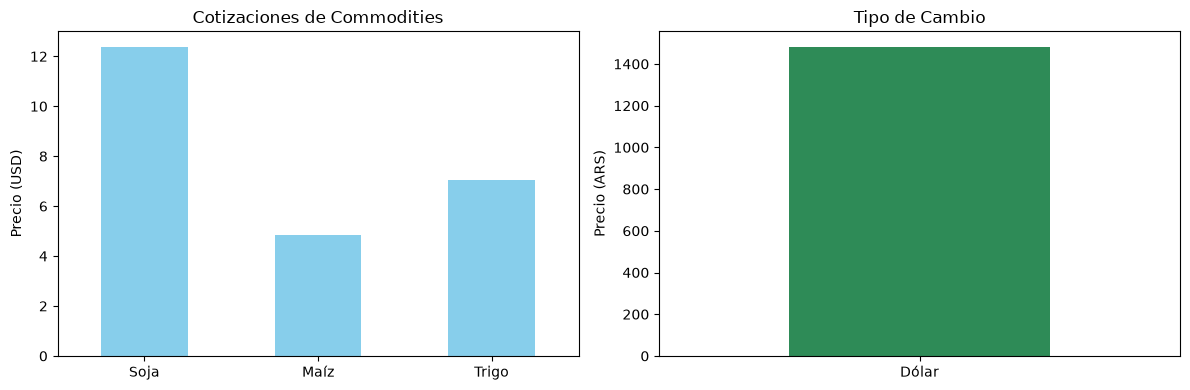

In [11]:
# Visualización tabular de cotizaciones actuales
if cotizaciones_actuales:
    df_cotizaciones = pd.DataFrame.from_dict(cotizaciones_actuales, orient='index')
    display(df_cotizaciones)

    # El Dólar (ARS por USD, ~miles) y los commodities (USD por bushel, de un dígito)
    # están en escalas totalmente distintas: graficarlos juntos deja los commodities
    # invisibles al lado de la barra del dólar. Los separamos en dos paneles.
    commodities = df_cotizaciones.drop(index='Dólar', errors='ignore')
    hay_dolar = 'Dólar' in df_cotizaciones.index

    fig, axes = plt.subplots(1, 2 if hay_dolar else 1, figsize=(12, 4))
    axes = np.atleast_1d(axes)

    if not commodities.empty:
        commodities['precio'].plot(kind='bar', ax=axes[0], color='skyblue')
        axes[0].set_title('Cotizaciones de Commodities')
        axes[0].set_ylabel('Precio (USD)')
        axes[0].tick_params(axis='x', rotation=0)

    if hay_dolar:
        df_cotizaciones.loc[['Dólar'], 'precio'].plot(kind='bar', ax=axes[-1], color='seagreen')
        axes[-1].set_title('Tipo de Cambio')
        axes[-1].set_ylabel('Precio (ARS)')
        axes[-1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de cotizaciones actuales disponibles.")

## 4. Visualización de Rentabilidad por Cultivo

Presenta los márgenes brutos y porcentuales por cultivo en formato tabular y gráfico, destacando el cultivo más rentable.

,cultivo,margen_bruto_usd,margen_porcentaje
0,Soja,189.125000,30.547143
1,Maíz,-21.741071,-2.793552
2,Trigo,29.687500,5.604720


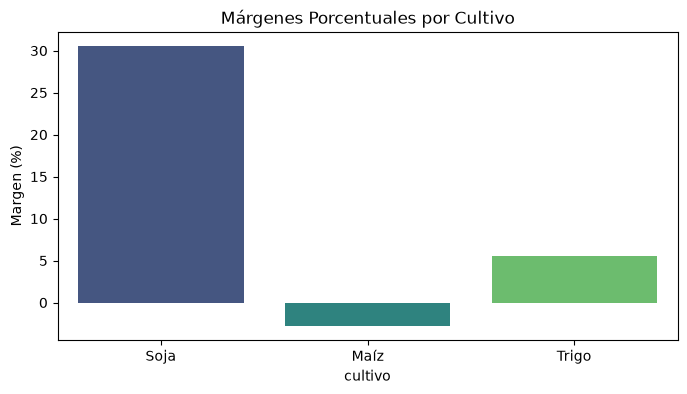

Cultivo más rentable: Soja (30.5% margen)


In [6]:
# Visualización de márgenes por cultivo
if resultados_margenes:
    df_margenes = pd.DataFrame(resultados_margenes)
    display(df_margenes[['cultivo','margen_bruto_usd','margen_porcentaje']])
    
    # Gráfico de márgenes porcentuales
    plt.figure(figsize=(8,4))
    sns.barplot(x='cultivo', y='margen_porcentaje', data=df_margenes, palette='viridis')
    plt.title('Márgenes Porcentuales por Cultivo')
    plt.ylabel('Margen (%)')
    plt.show()
    
    # Destacar el cultivo más rentable
    mejor = df_margenes.loc[df_margenes['margen_porcentaje'].idxmax()]
    print(f"Cultivo más rentable: {mejor['cultivo']} ({mejor['margen_porcentaje']:.1f}% margen)")
else:
    print("No hay datos de márgenes disponibles.")

## 5. Visualización de Alertas Críticas

Muestra las alertas comerciales detectadas, clasificadas por urgencia, con acciones recomendadas y fundamentos.

,commodity,tipo,urgencia,accion,fundamento
0,Soja,VENTA,ALTA,Vender el stock disponible,"Precio en percentil 100%, cerca de máximos his..."
1,Maíz,VENTA,ALTA,Vender el stock disponible,"Precio en percentil 100%, cerca de máximos his..."
2,Trigo,VENTA,ALTA,Vender el stock disponible,"Precio en percentil 100%, cerca de máximos his..."


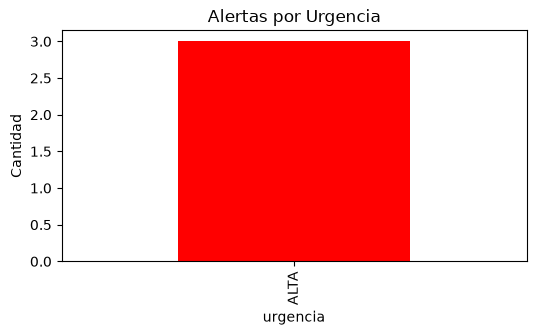

In [7]:
# Visualización de alertas comerciales
if oportunidades:
    df_alertas = pd.DataFrame(oportunidades)
    display(df_alertas[['commodity','tipo','urgencia','accion','fundamento']])
    
    # Conteo por urgencia
    urgencias = df_alertas['urgencia'].value_counts()
    plt.figure(figsize=(6,3))
    urgencias.plot(kind='bar', color=['red','orange','green'])
    plt.title('Alertas por Urgencia')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print("No hay alertas comerciales disponibles.")

## 6. Visualización de Recomendación Estratégica

Resume la estrategia sugerida (venta activa, retención, venta gradual) y muestra el análisis del tipo de cambio.

In [8]:
# Resumen de estrategia sugerida y tipo de cambio
if cotizaciones_actuales and resultados_margenes:
    # Estrategia general basada en alertas
    alertas_venta = len([a for a in oportunidades if 'VENTA' in a.get('tipo','')]) if oportunidades else 0
    alertas_retencion = len([a for a in oportunidades if 'RETENER' in a.get('tipo','') or 'ACUMULAR' in a.get('tipo','')]) if oportunidades else 0
    if alertas_venta > alertas_retencion:
        estrategia = "VENTA ACTIVA - Aprovechar precios favorables"
    elif alertas_retencion > alertas_venta:
        estrategia = "RETENCIÓN ESTRATÉGICA - Esperar mejores oportunidades"
    else:
        estrategia = "VENTA GRADUAL - Diversificar timing comercial"
    print(f"Estrategia sugerida: {estrategia}")
    # Análisis del dólar
    if 'Dólar' in cotizaciones_actuales:
        tipo_cambio = cotizaciones_actuales['Dólar']['precio']
        if tipo_cambio > 1200:
            print(f"Dólar: ${tipo_cambio:.0f} ARS (ALTO) - Favorable para liquidación")
        elif tipo_cambio < 900:
            print(f"Dólar: ${tipo_cambio:.0f} ARS (BAJO) - Considerar retener granos")
        else:
            print(f"Dólar: ${tipo_cambio:.0f} ARS (NORMAL) - Evaluar por commodity")
else:
    print("No hay datos suficientes para estrategia.")

Estrategia sugerida: VENTA ACTIVA - Aprovechar precios favorables
Dólar: $1482 ARS (ALTO) - Favorable para liquidación


## 7. Panel de Próximas Acciones

Lista las acciones recomendadas para los próximos días, como monitoreo de alertas y revisión del dashboard.

In [9]:
# Panel de acciones recomendadas
acciones = [
    "1. Revisar este dashboard cada 24 horas",
    "2. Monitorear alertas de alta urgencia diariamente",
    "3. Evaluar oportunidades de venta según análisis de márgenes",
    "4. Considerar estrategias de cobertura para commodities volátiles",
    "5. Consultar con asesor financiero para decisiones de gran volumen"
 ]
for accion in acciones:
    print(accion)

1. Revisar este dashboard cada 24 horas
2. Monitorear alertas de alta urgencia diariamente
3. Evaluar oportunidades de venta según análisis de márgenes
4. Considerar estrategias de cobertura para commodities volátiles
5. Consultar con asesor financiero para decisiones de gran volumen


## 8. Estadísticas de Ejecución

Presenta estadísticas de ejecución: número de commodities analizados, alertas generadas y tiempo estimado de ejecución.

In [ ]:
# Estadísticas de ejecución
commodities_analizados = len(cotizaciones_actuales) if cotizaciones_actuales else 0
alertas_generadas = len(oportunidades) if oportunidades else 0
tiempo_ejecucion = '<30 segundos'
print(f"Commodities analizados: {commodities_analizados}")
print(f"Alertas generadas: {alertas_generadas}")
print(f"Tiempo de ejecución estimado: {tiempo_ejecucion}")
print(f"Próxima actualización sugerida: {(datetime.now() + timedelta(hours=24)).strftime('%d/%m/%Y %H:%M')}")